In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import multivariate_logrank_test

clean = pd.read_csv("../data/processed/telco_clean.csv").set_index("CustomerID")
features = pd.read_csv("../data/processed/telco_features.csv", index_col="CustomerID")

surv = clean.loc[clean["Tenure Months"] > 0,
                 ["Tenure Months", "Churn Value", "Contract", "Internet Service", "Payment Method"]].copy()
print(surv.shape, surv["Churn Value"].sum())

(7032, 5) 1869


In [2]:
kmf = KaplanMeierFitter()
kmf.fit(surv["Tenure Months"], event_observed=surv["Churn Value"], label="All customers")

print(kmf.predict([3, 6, 12, 24, 36, 48, 60, 72]).round(3))
print("Median lifetime:", kmf.median_survival_time_)

3     0.914
6     0.885
12    0.843
24    0.789
36    0.749
48    0.709
60    0.664
72    0.593
Name: All customers, dtype: float64
Median lifetime: inf


Month-to-month               n= 3875 | S(12)=0.703 S(24)=0.586 S(48)=0.397 S(72)=0.129 | median=35.0
One year                     n= 1472 | S(12)=0.991 S(24)=0.978 S(48)=0.917 S(72)=0.568 | median=inf
Two year                     n= 1685 | S(12)=1.000 S(24)=1.000 S(48)=0.996 S(72)=0.936 | median=inf

DSL                          n= 2416 | S(12)=0.868 S(24)=0.831 S(48)=0.785 S(72)=0.722 | median=inf
Fiber optic                  n= 3096 | S(12)=0.784 S(24)=0.702 S(48)=0.581 S(72)=0.417 | median=65.0
No                           n= 1520 | S(12)=0.935 S(24)=0.926 S(48)=0.918 S(72)=0.902 | median=inf


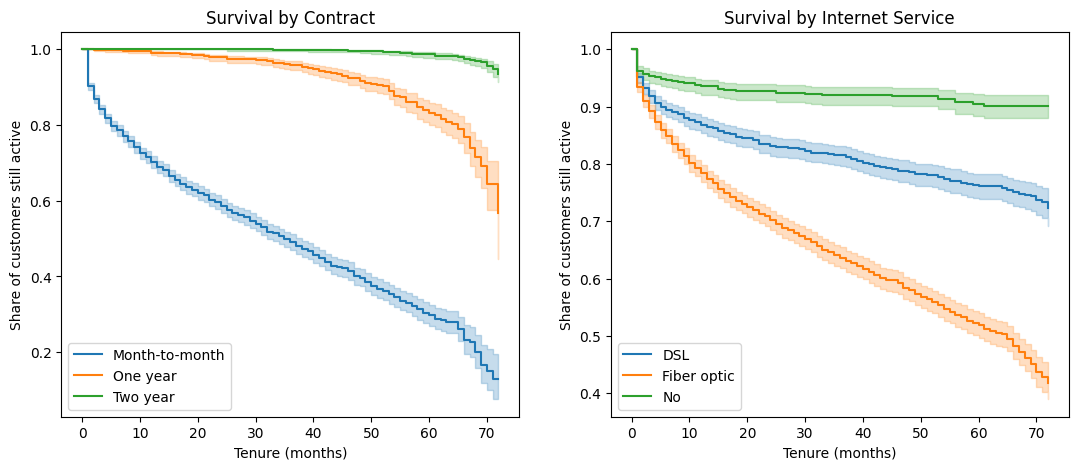

In [3]:
def km_by(column, ax):
    for value, group in surv.groupby(column):
        k = KaplanMeierFitter()
        k.fit(group["Tenure Months"], event_observed=group["Churn Value"], label=value)
        k.plot_survival_function(ax=ax)
        print(f"{value:28s} n={len(group):>5} | S(12)={k.predict(12):.3f} S(24)={k.predict(24):.3f} "
              f"S(48)={k.predict(48):.3f} S(72)={k.predict(72):.3f} | median={k.median_survival_time_}")
    ax.set_xlabel("Tenure (months)")
    ax.set_ylabel("Share of customers still active")
    ax.set_title(f"Survival by {column}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
km_by("Contract", axes[0])
print()
km_by("Internet Service", axes[1])
plt.savefig("../reports/km_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [4]:
for col in ["Contract", "Internet Service"]:
    result = multivariate_logrank_test(surv["Tenure Months"], surv[col], surv["Churn Value"])
    print(f"{col}: test statistic = {result.test_statistic:.1f}, p-value = {result.p_value:.2e}")

Contract: test statistic = 2352.9, p-value = 0.00e+00
Internet Service: test statistic = 520.1, p-value = 1.14e-113


In [5]:
def piecewise_hazard(d, lo, hi):
    exposure = (np.clip(d["Tenure Months"], lo, hi) - lo).sum()
    events = ((d["Tenure Months"] > lo) & (d["Tenure Months"] <= hi) & (d["Churn Value"] == 1)).sum()
    return events / exposure * 100 if exposure > 0 else np.nan

intervals = [(0, 12), (12, 24), (24, 48), (48, 72)]
hazards = pd.DataFrame({
    contract: {f"{lo+1}-{hi}": piecewise_hazard(g, lo, hi) for lo, hi in intervals}
    for contract, g in surv.groupby("Contract")
}).T
print(hazards.round(2))
print((hazards.loc["Month-to-month"] / hazards.loc["One year"]).round(1))

                1-12  13-24  25-48  49-72
Month-to-month  3.25   1.53   1.56   2.70
One year        0.08   0.11   0.25   1.06
Two year        0.00   0.00   0.02   0.19
1-12     42.9
13-24    14.5
25-48     6.2
49-72     2.5
dtype: float64


In [6]:
covariates = ["Senior Citizen", "Partner", "Dependents", "Paperless Billing",
              "Online Security", "Online Backup", "Device Protection", "Tech Support",
              "Streaming TV", "Streaming Movies",
              "Multiple Lines_No phone service", "Multiple Lines_Yes",
              "Internet Service_Fiber optic", "Internet Service_No",
              "Contract_One year", "Contract_Two year",
              "Payment Method_Credit card (automatic)", "Payment Method_Electronic check",
              "Payment Method_Mailed check"]

cox_df = features.loc[surv.index, covariates].join(surv[["Tenure Months", "Churn Value"]])

cph = CoxPHFitter()
cph.fit(cox_df, duration_col="Tenure Months", event_col="Churn Value")

hr = cph.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]]
print(hr.sort_values("exp(coef)", ascending=False).round(3))
print("Concordance (in-sample):", round(cph.concordance_index_, 3))

                                        exp(coef)  exp(coef) lower 95%  \
covariate                                                                
Payment Method_Electronic check             1.768                1.537   
Payment Method_Mailed check                 1.755                1.477   
Internet Service_Fiber optic                1.385                1.202   
Paperless Billing                           1.190                1.065   
Streaming TV                                0.960                0.863   
Payment Method_Credit card (automatic)      0.921                0.771   
Multiple Lines_No phone service             0.885                0.726   
Senior Citizen                              0.873                0.782   
Streaming Movies                            0.853                0.766   
Device Protection                           0.718                0.645   
Partner                                     0.697                0.630   
Tech Support                          

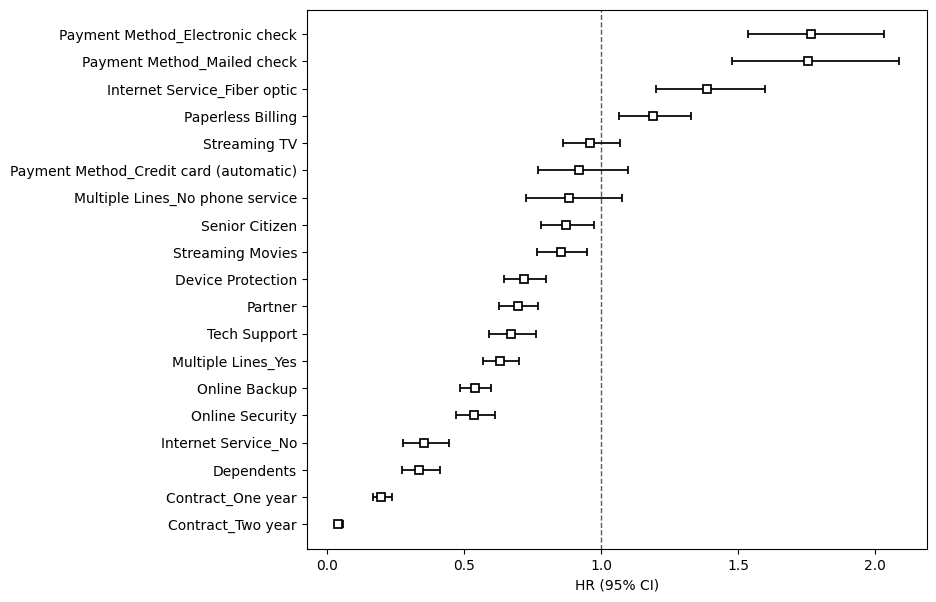

In [7]:
fig, ax = plt.subplots(figsize=(8, 7))
cph.plot(hazard_ratios=True, ax=ax)
plt.savefig("../reports/cox_hazard_ratios.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
cph.check_assumptions(cox_df, p_value_threshold=0.01, show_plots=False)

The ``p_value_threshold`` is set at 0.01. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'Partner' failed the non-proportional test: p-value is 0.0014.

   Advice: with so few unique values (only 2), you can include `strata=['Partner', ...]` in the call
in `.fit`. See documentation in link [E] below.

2. Variable 'Dependents' failed the non-proportional test: p-value is <5e-05.

   Advice: with so few unique values (only 2), you can include `strata=['Dependents', ...]` in the
call in `.fit`. See documentation in link [E] below.

3. Variable 'Online Security' failed the non-proportional test: p-value is 0.0003.

   Advice: with so few unique values (only 2), you can include `strata=['Online Security', ...]` in
the call in `.fit`. See documentation in link [E] below.

4. Variable 'Online Backup' failed the non-proportional test: p-value is 0.0008.

   Advice: with so few unique values (only 2), you can include `strata=['Online Backup', ...]` in
the call in `.fit`. See documentation in link [E] below.

5. Variable 'Tech Support' failed the non-proportional test:

[]

In [9]:
strat_covs = [c for c in covariates if not c.startswith("Contract_")]
strat_df = features.loc[surv.index, strat_covs].join(surv[["Tenure Months", "Churn Value", "Contract"]])

cph_s = CoxPHFitter()
cph_s.fit(strat_df, duration_col="Tenure Months", event_col="Churn Value", strata=["Contract"])

compare = pd.DataFrame({"Main model": cph.summary["exp(coef)"],
                        "Stratified by contract": cph_s.summary["exp(coef)"]}).round(3)
print(compare.dropna())

                                        Main model  Stratified by contract
covariate                                                                 
Dependents                                   0.336                   0.331
Device Protection                            0.718                   0.734
Internet Service_Fiber optic                 1.385                   1.375
Internet Service_No                          0.353                   0.376
Multiple Lines_No phone service              0.885                   0.895
Multiple Lines_Yes                           0.632                   0.634
Online Backup                                0.540                   0.550
Online Security                              0.539                   0.542
Paperless Billing                            1.190                   1.187
Partner                                      0.697                   0.712
Payment Method_Credit card (automatic)       0.921                   0.921
Payment Method_Electronic

In [10]:
profiles = pd.DataFrame(0, index=["High-risk", "Low-risk traits, month-to-month", "Low-risk traits, two-year"],
                        columns=strat_covs)
profiles["Contract"] = ["Month-to-month", "Month-to-month", "Two year"]

profiles.loc["High-risk", ["Internet Service_Fiber optic", "Payment Method_Electronic check",
                           "Paperless Billing", "Multiple Lines_Yes",
                           "Streaming TV", "Streaming Movies"]] = 1
low_traits = ["Payment Method_Credit card (automatic)", "Dependents", "Partner",
              "Online Security", "Online Backup", "Tech Support"]
profiles.loc[["Low-risk traits, month-to-month", "Low-risk traits, two-year"], low_traits] = 1

for tenure in [3, 24]:
    fn = cph_s.predict_survival_function(profiles, times=[3, 6, 12],
                                         conditional_after=[tenure] * len(profiles))
    result = (1 - fn).T
    result.columns = ["next 3 months", "next 6 months", "next 12 months"]
    print(f"Customers who have already stayed {tenure} months, chance of leaving:")
    print(result.round(3), "\n")

Customers who have already stayed 3 months, chance of leaving:
                                 next 3 months  next 6 months  next 12 months
High-risk                                0.130          0.232           0.400
Low-risk traits, month-to-month          0.004          0.007           0.014
Low-risk traits, two-year                0.000          0.000           0.000 

Customers who have already stayed 24 months, chance of leaving:
                                 next 3 months  next 6 months  next 12 months
High-risk                                0.107          0.205           0.391
Low-risk traits, month-to-month          0.003          0.007           0.014
Low-risk traits, two-year                0.000          0.000           0.000 



In [11]:
hr.sort_values("exp(coef)", ascending=False).round(4).to_csv("../reports/cox_hazard_ratios.csv")